In [1]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [5]:
# Veri Seti Ekleme
df_apt = pd.read_csv('/content/sample_data/apartments_for_rent_classified_100K.csv', sep=';', encoding='cp1252')
df_apt.head(2)

df_apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

In [7]:
# Regresyon için özelliklerin ve Hedefin ayrılması
features = ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
df_clean = df_apt[['price'] + features].dropna()

X_reg = df_clean[features]
y_reg = df_clean['price']

In [8]:
y_reg

,price
0,2195.0
1,1250.0
2,1395.0
3,1600.0
4,975.0
...,...
99487,780.0
99488,813.0
99489,1325.0
99490,931.0


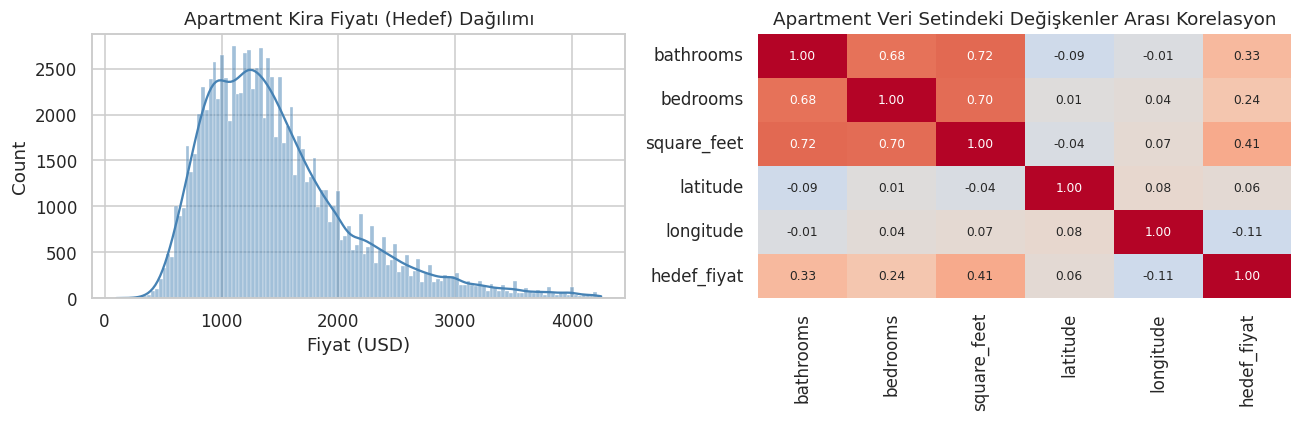

In [9]:
#Hedef Değişken Dağılımı ve Özellikler Arası Korelasyon Isı Haritası
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dağılımı daha rahat görebilmek için aşırı uçları sınırlayarak çizdiriyoruz
price_plot = y_reg[y_reg <= y_reg.quantile(0.99)]
sns.histplot(price_plot, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Apartment Kira Fiyatı (Hedef) Dağılımı")
axes[0].set_xlabel("Fiyat (USD)")

# Korelasyon matrisi
corr = pd.concat([X_reg, y_reg.rename("hedef_fiyat")], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            axes=axes[1], cbar=False, annot_kws={"size": 8})
axes[1].set_title("Apartment Veri Setindeki Değişkenler Arası Korelasyon")

plt.tight_layout()
plt.show()

In [10]:
#Eğitim ve Test Kümelerine Ayırma (train_test_split)
from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

print(f"Eğitim seti satır sayısı: {Xr_train.shape[0]}")
print(f"Test seti satır sayısı: {Xr_test.shape[0]}")

Eğitim seti satır sayısı: 79424
Test seti satır sayısı: 19856


In [11]:
#Temel (Baseline) ve Doğrusal Regresyon (Linear) Kıyaslaması
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
linear = LinearRegression().fit(Xr_train, yr_train)

def regresyon_raporu(model, X, y, ad):
    tahmin = model.predict(X)
    return {
        "Model": ad,
        "Mae": mean_absolute_error(y, tahmin),
        "mse": mean_squared_error(y, tahmin),
        "rmse": np.sqrt(mean_squared_error(y, tahmin)),
        "r2": r2_score(y, tahmin)
    }

sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_train, yr_train, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Linear")
]).set_index("Model").round(3)

sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,546.821,828776.924,910.372,0.000
Linear,498.806,574818.015,758.168,0.215


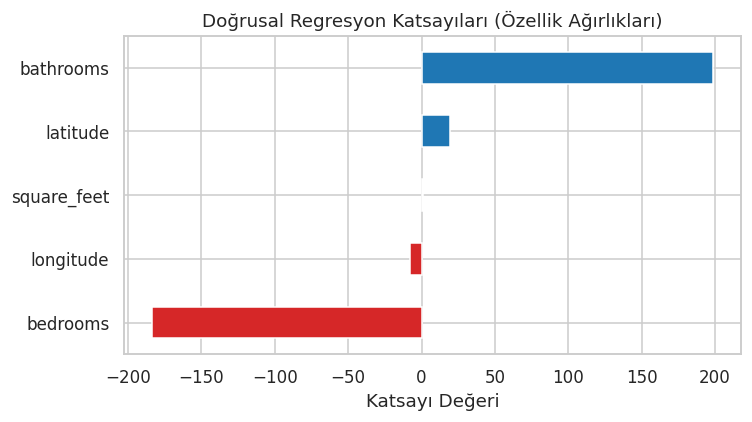

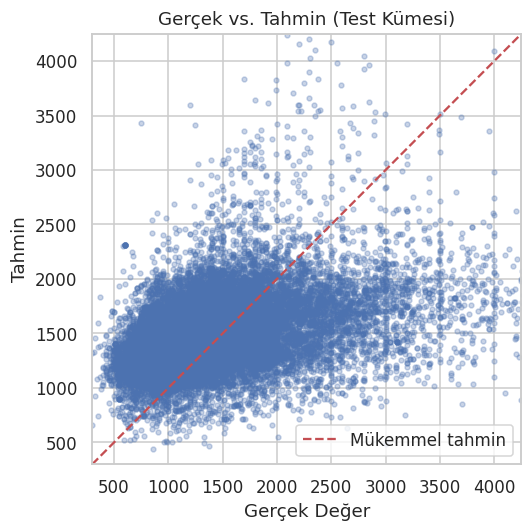

In [12]:
#Katsayıların ve Gerçek vs Tahmin Değerlerinin Görselleştirilmesi
# 1. Katsayı Çubuğu Grafiği
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal Regresyon Katsayıları (Özellik Ağırlıkları)")
plt.xlabel("Katsayı Değeri")
plt.tight_layout()
plt.show()

# 2. Gerçek vs Tahmin Dağılım Grafiği
tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.3, s=10)
lim = [yr_test.min(), yr_test.quantile(0.99)] # Uç değerler dışı net görünüm
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlim(lim)
plt.ylim(lim)
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (Test Kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
#Düzenlileştirme (Regularization) Modelleri: Doğrusal, Ridge ve Lasso
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0))
}

satirlar = []
for ad, m in modeller.items():
    m.fit(Xr_train, yr_train)
    satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,498.806,574818.015,758.168,0.215
Ridge,498.805,574818.056,758.168,0.215
Lasso,498.636,574863.177,758.197,0.215


In [14]:
#Lasso Katsayılarının İncelenmesi (Özellik Seçimi)
lasso = modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_, index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,bathrooms,bedrooms,square_feet,latitude,longitude
Lasso değişkenler,106.87,-133.27,400.44,86.49,-122.27


In [15]:
#Model isimlerini ekrana dökme
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])


In [18]:
# Kiralık daire veri setinden özelliklerin ve ikili sınıflandırma hedefinin tanımlanması
features = ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
df_clean = df_apt[['price'] + features].dropna()

X_clf = df_clean[features]
# Hedef: Medyan ve üzeri fiyatlar = 1 (Yüksek Fiyat), altı = 0 (Ekonomik Fiyat)
fiyat_esik = df_clean['price'].median()
y_clf = (df_clean['price'] >= fiyat_esik).astype(int)

X_clf.head(2)


,bathrooms,bedrooms,square_feet,latitude,longitude
0,1.0,1.0,542,33.8520,-118.3759
1,1.5,3.0,1500,37.0867,-76.4941


In [19]:
#Sınıf Dağılımı ve Özelliklerin Betimsel İstatistikleri
print(f"Sınıf dağılımı (Eşik: {fiyat_esik:.0f} USD | 0=Ekonomik, 1=Yüksek Fiyat):")
print(y_clf.value_counts().rename({0: "Ekonomik", 1: "Yüksek Fiyat"}))

X_clf.describe().T.round(2)

Sınıf dağılımı (Eşik: 1350 USD | 0=Ekonomik, 1=Yüksek Fiyat):
price
Yüksek Fiyat    50103
Ekonomik        49177
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
bathrooms,99280.0,1.45,0.55,1.00,1.00,1.00,2.00,9.00
bedrooms,99280.0,1.73,0.75,0.00,1.00,2.00,2.00,9.00
square_feet,99280.0,956.07,365.36,107.00,730.00,900.00,1116.00,12000.00
latitude,99280.0,36.95,4.60,19.57,33.75,37.23,39.95,64.83
longitude,99280.0,-91.56,15.81,-159.37,-104.79,-84.56,-77.61,-68.78


In [20]:
# Eğitim ve test setlerini ayırma
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED)

In [21]:
# Baseline (kukla) modele karşı; Logistic Regression, KNN, Karar Ağacı ve Rastgele Orman modelleri eğitilir.
#Mesafe ve doğrusal temelli modeller için Pipeline ile standartlaştırma uygulanır.
#Eğitim ve test kümesi doğruluk skorları bir tabloda kıyaslanır.

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train),
    "Logistic": make_pipeline(StandardScaler(), LogisticRegression()).fit(Xc_train, yc_train),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(Xc_train, yc_train),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED).fit(Xc_train, yc_train),
    "Rastgele orman": RandomForestClassifier(random_state=SEED).fit(Xc_train, yc_train)
}

satirlar = []

for ad, m in siniflandiricilar.items():
    m.fit(Xc_train, yc_train)
    satirlar.append(
        {
            "Model": ad,
            "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
            "Test": accuracy_score(yc_test, m.predict(Xc_test))
        }
    )

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.505,0.505
Logistic,0.652,0.647
KNN,0.906,0.862
Karar ağacı,0.987,0.891
Rastgele orman,0.987,0.910


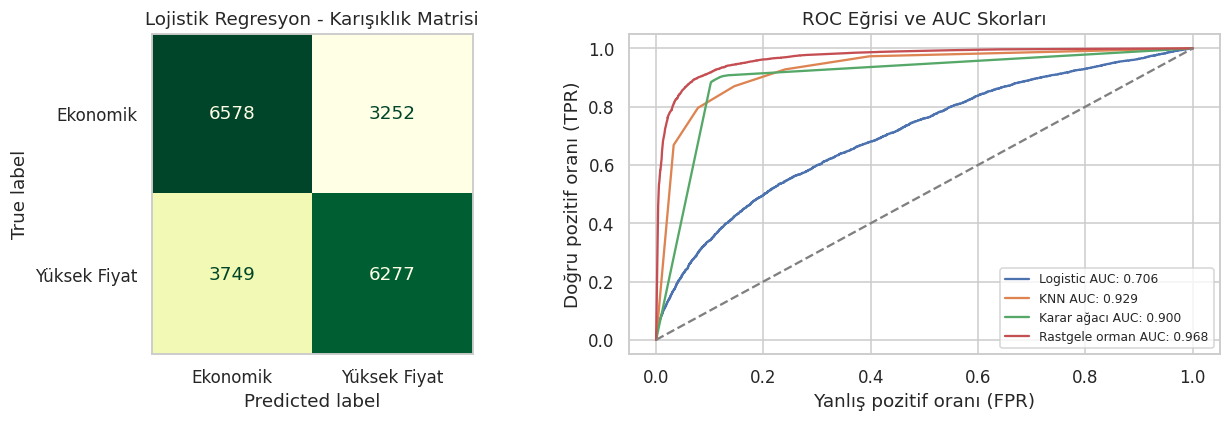

In [22]:
#Solda Lojistik Regresyon modelinin doğru ve yanlış tahmin sayılarını gösteren karışıklık matrisi,
#sağda ise tüm modellerin ayrım gücünü kıyaslayan ROC eğrileri ve AUC skorları çizdirilir.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)
olasilik = model.predict_proba(Xc_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Karışıklık Matrisi
ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin,
    display_labels=["Ekonomik", "Yüksek Fiyat"],
    cmap="YlGn", ax=axes[0], colorbar=False
)
axes[0].set_title("Lojistik Regresyon - Karışıklık Matrisi")
axes[0].grid(False)

# ROC Eğrileri
for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} AUC: {roc_auc_score(yc_test, p):.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış pozitif oranı (FPR)")
axes[1].set_ylabel("Doğru pozitif oranı (TPR)")
axes[1].set_title("ROC Eğrisi ve AUC Skorları")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
#Modellerin eğitim kümesindeki istikrarını ve genelleme gücünü ölçmek için veri 5 eşit katlamaya bölünerek çapraz doğrulama yapılır.
#Ortalama doğruluk skoru ve standart sapma değerleri raporlanır.

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
satirlar = []

for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({
        "Model": ad,
        "Ortalama skor": skorlar.mean(),
        "Standart sapma": skorlar.std()
    })

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,0.905,0.001
Karar ağacı,0.886,0.002
KNN,0.861,0.001
Logistic,0.652,0.004
Baseline,0.505,0.000


In [24]:
#Standartlaştırılmış KNN modeli üzerinde en iyi komşu sayısı (n_neighbors) ve ağırlık fonksiyonu (weights)
#ızgara araması (GridSearchCV) ile taranarak en yüksek başarıyı veren en uygun parametre seti tespit edilir.

from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("En iyi parametreler:", opt.best_params_)
print(f"En iyi CV Skoru: {opt.best_score_:.4f}")

En iyi parametreler: {'kneighborsclassifier__n_neighbors': 21, 'kneighborsclassifier__weights': 'distance'}
En iyi CV Skoru: 0.8881


In [25]:
scaler_yanlis= StandardScaler().fit(X_clf)
Xc_tr= scaler_yanlis.transform(Xc_train)
Xc_te= scaler_yanlis.transform(Xc_test)

In [26]:
scaler_dogru = StandardScaler().fit(Xc_train)
Xc_tr= scaler_dogru.transform(Xc_train)
Xc_te= scaler_dogru.transform(Xc_test)

In [27]:
print("yanlış yöntem " ,scaler_yanlis.mean_[:3].round(2))
print("doğru yöntem" ,scaler_dogru.mean_[:3].round(2))

yanlış yöntem  [  1.45   1.73 956.07]
doğru yöntem [  1.45   1.73 955.69]


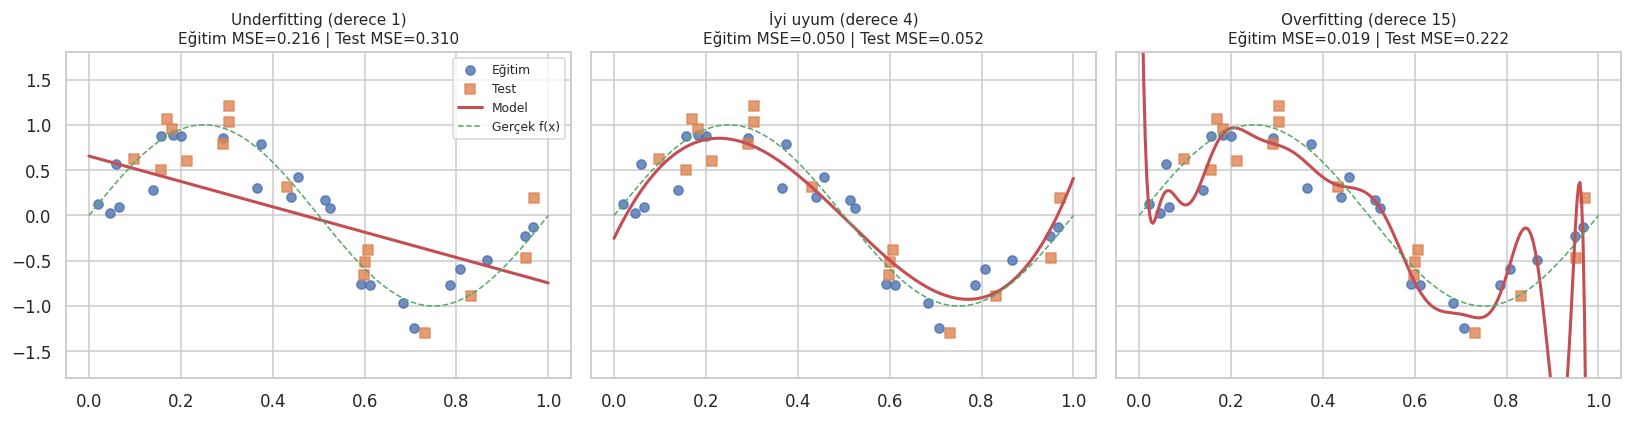

In [28]:
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.RandomState(SEED)
n = 40
x = np.sort(rng.uniform(0, 1, n))
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, n)  # gerçek fonksiyon + gürültü

x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y, test_size=0.4, random_state=SEED)

xs = np.linspace(0, 1, 300).reshape(-1, 1)
dereceler = [1, 4, 15]
basliklar = ["Underfitting (derece 1)", "İyi uyum (derece 4)", "Overfitting (derece 15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d, b in zip(axes, dereceler, basliklar):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    tr_hata = mean_squared_error(y_tr, model.predict(x_tr))
    te_hata = mean_squared_error(y_te, model.predict(x_te))
    ax.scatter(x_tr, y_tr, label="Eğitim", alpha=0.8)
    ax.scatter(x_te, y_te, label="Test", alpha=0.8, marker="s")
    ax.plot(xs, model.predict(xs), "r-", lw=2, label="Model")
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, label="Gerçek f(x)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"{b}\nEğitim MSE={tr_hata:.3f} | Test MSE={te_hata:.3f}", fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

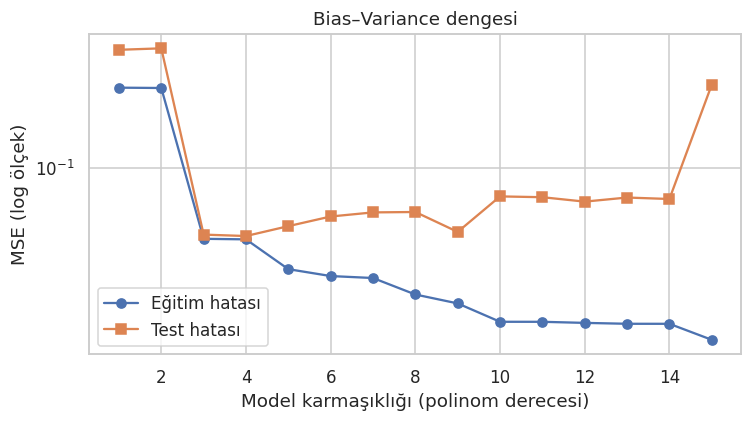

Test hatasının en düşük olduğu derece: 4


In [29]:
# Model karmaşıklığı arttıkça eğitim ve test hatası nasıl değişir?
derece_araligi = range(1, 16)
egitim_hatalari, test_hatalari = [], []

for d in derece_araligi:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    egitim_hatalari.append(mean_squared_error(y_tr, model.predict(x_tr)))
    test_hatalari.append(mean_squared_error(y_te, model.predict(x_te)))

plt.figure(figsize=(7, 4))
plt.plot(derece_araligi, egitim_hatalari, "o-", label="Eğitim hatası")
plt.plot(derece_araligi, test_hatalari, "s-", label="Test hatası")
plt.yscale("log")
plt.xlabel("Model karmaşıklığı (polinom derecesi)")
plt.ylabel("MSE (log ölçek)")
plt.title("Bias–Variance dengesi")
plt.legend()
plt.tight_layout()
plt.show()

en_iyi = list(derece_araligi)[int(np.argmin(test_hatalari))]
print(f"Test hatasının en düşük olduğu derece: {en_iyi}")

# K Means

1.   Rastgele k merkez(centroid) seç
2.   Her örneği en yakın zamanda ata
1.   Merkezleri ,atanan örnekleri ortalaması
2.   Atamalarr değişmene kadar 2-3 tekrarla









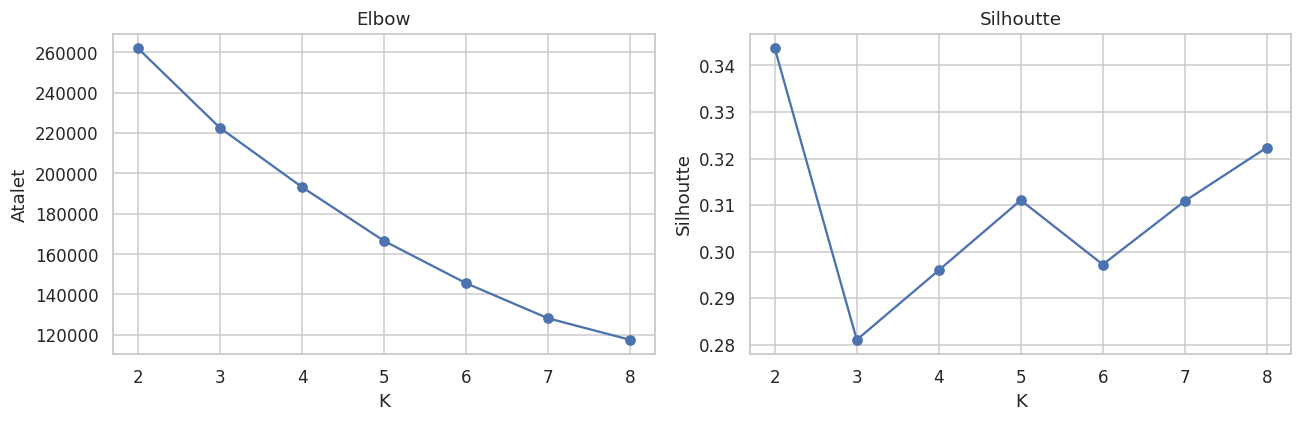

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

k_degerleri = range(2,9)
atalet, silhoutte= [],[]

for k in k_degerleri:
  km=KMeans(n_clusters=k, n_init=10,random_state=SEED).fit(Xc_tr)
  atalet.append(km.inertia_)
  silhoutte.append(silhouette_score(Xc_tr,km.labels_))


fig, axes =plt.subplots(1,2,figsize=(12,4))

axes[0].plot(k_degerleri,atalet,marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Atalet")

axes[1].plot(k_degerleri,silhoutte,marker="o")
axes[1].set_title("Silhoutte")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhoutte")

plt.tight_layout()
plt.show()
